In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

from scipy.sparse import vstack, load_npz
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as skm
import sklearn.utils as sku

import torch as pt
import torch.nn as nn
import torch.optim as optim

from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader

import optuna as opt

import Basic_functions as bf

from torchao.sparsity.training import (
    SemiSparseLinear,
    SemiSparseActivationLinear,
    swap_linear_with_semi_sparse_linear,
    swap_semi_sparse_linear_with_linear,
)

import numpy as np
from scipy import sparse
from scipy.sparse import load_npz, hstack
from sklearn.preprocessing import StandardScaler, LabelEncoder
import sklearn.utils as sku

from tqdm.auto import tqdm

# Optional imports
# from torch.nn import L1Loss
# from scipy.special import expit

W0607 19:57:09.865000 16234 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
DATA_FILE = "/Users/psf728/Desktop/data_nltk.npz"
LABEL_FILE = "Data_files/labels_nltk.txt"
SORT_FILE = "txt_files/multiclass_nltk_sort_idx.txt"

# Load
labels = np.genfromtxt(LABEL_FILE, delimiter=";", dtype=str, skip_header=1)
X = load_npz(DATA_FILE)
sort_idx = np.genfromtxt(SORT_FILE, dtype=int)

print("Loaded:", X.shape)

# Keep articles only
article_mask = np.abs(labels[:, 2].astype(int) - 1) == 0
X = X[article_mask]
labels = labels[article_mask]

print("After article filter:", X.shape)

# Add LIX score
lix = sparse.csr_matrix(labels[:, 0].astype(float).reshape(-1, 1))
X = hstack([lix, X], format="csr")

print("After LIX feature:", X.shape)

# Keep top 500 features
sort_idx = sort_idx[sort_idx < X.shape[1]]
X = X[:, sort_idx][:, :20000]

print("After feature selection:", X.shape)

# Scale
X = StandardScaler(with_mean=False).fit_transform(X)

print("After scaling:", X.shape)

# Keep top 10 topics
topics = labels[:, 1]

unique_topics, counts = np.unique(topics, return_counts=True)
top_topics = unique_topics[np.argsort(counts)[::-1][:10]]

mask = np.isin(topics, top_topics)

X = X[mask]
topics = topics[mask]

print("After top-10 topic filter:", X.shape)

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(topics)

print("After label encoding:")
print("  X:", X.shape)
print("  y:", y.shape)

# Shuffle
X, y = sku.shuffle(X, y, random_state=5466542)

print("After shuffle:")
print("  X:", X.shape)
print("  y:", y.shape)

# Split
data_train, data_train_labels, \
data_val, data_val_labels, \
data_test, data_test_labels = bf.train_val_test_split(
    X, y,
    val_size=0.20,
    test_size=0.0
)

print("Train:", data_train.shape)
print("Val:  ", data_val.shape)
print("Test: ", data_test.shape)

Loaded: (780044, 64478)
After article filter: (775291, 64478)
After LIX feature: (775291, 64479)
After feature selection: (775291, 20000)
After scaling: (775291, 20000)
After top-10 topic filter: (434564, 20000)
After label encoding:
  X: (434564, 20000)
  y: (434564,)
After shuffle:
  X: (434564, 20000)
  y: (434564,)
Train: (347652, 20000)
Val:   (86912, 20000)
Test:  (0, 20000)


# Functions

In [ ]:
class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return self.truth.shape[0]

#In pytorch, there is an additional step of turning your data into tensors
train_data = MyDataset(data_train, data_train_labels)
val_data = MyDataset(data_val, data_val_labels)

# Training loop:
def Train(model, optimizer, loss_function, train_loader, validation_loader, device, epochs):
    validation_loss = []
    training_loss   = []
    model.train()
    for e in range(0, epochs):
        epoch_loss = 0
        n_minibatches = 0
        for input_train_batch, truth_train_batch in train_loader:
            input_train_batch, truth_train_batch = input_train_batch.to(device), truth_train_batch.to(device)
            optimizer.zero_grad()
            prediction = model(input_train_batch)  # This asks our model to produce predictions on the training batch            
            loss = loss_function(prediction, truth_train_batch.long())  # This calculates the loss
            loss.backward()                                             # This initiates the backpropagation
            optimizer.step()
            epoch_loss += loss.item()
            n_minibatches += 1
        
        # Now that the model have trained 1 epoch, we evaluate the model on the validation set:
        valid_loss = Validate(model, validation_loader, device, loss_function)
        validation_loss.append(valid_loss)
        training_loss.append(epoch_loss/n_minibatches)
        print('EPOCH: %s | training loss: %s  | validation loss: %s'%(e+1,round(epoch_loss/n_minibatches,3), round(valid_loss, 3)))
    return training_loss, validation_loss


def Validate(model, validation_loader, device, loss_function):
    model.eval()
    n_batches  = 0
    validation_loss = 0
    with pt.no_grad():
        for input_valid_batch, truth_valid_batch in validation_loader:
            input_valid_batch, truth_valid_batch = input_valid_batch.to(device), truth_valid_batch.to(device)
            prediction = model(input_valid_batch)
            loss = loss_function(prediction, truth_valid_batch.long())
            validation_loss += loss.item()
            n_batches += 1
    validation_loss = validation_loss/n_batches
    return validation_loss


def Predict(model, prediction_loader, device):
    model.eval()
    predictions = []
    print('PREDICTING!')
    with pt.no_grad():
        for input_pred_batch, _ in prediction_loader:
            input_pred_batch = input_pred_batch.to(device)
            prediction = model(input_pred_batch)
            predictions.extend(prediction.numpy())
    print('Done Predicting!')
    return predictions
                
class MeanRelativeAbsoluteDeviationLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
                
    def forward(self, prediction, target):
        prediction = prediction.view_as(target)
        relative_absolute_error = pt.abs(prediction - target) / (pt.abs(target) + self.eps)
        return pt.mean(relative_absolute_error)
    
def sparse_collate(batch):
    xs, ys = zip(*batch)

    first = xs[0]
    n_features = first.shape[-1]

    batch_rows = []
    batch_cols = []
    batch_vals = []

    for i, x in enumerate(xs):
        x = x.tocoo()
        batch_rows.append(np.full_like(x.col, i, dtype=np.int64))
        batch_cols.append(x.col.astype(np.int64))
        batch_vals.append(x.data.astype(np.float32))

    indices = pt.tensor(
        np.vstack([np.concatenate(batch_rows), np.concatenate(batch_cols)]),
        dtype=pt.long
    )
    values = pt.tensor(np.concatenate(batch_vals), dtype=pt.float32)

    X = pt.sparse_coo_tensor(indices, values, size=(len(xs), n_features)).coalesce()
    y = pt.tensor(np.asarray(ys), dtype=pt.long)
    return X, y

n_mult = 2


N_TRIALS = 40
N_EPOCHS = 5

trial_progress = tqdm(total=N_TRIALS, desc="Optuna trials", position=0)


def objective(trial):

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128]
    )

    Layer1 = trial.suggest_int("Layer1", 64, 256 * n_mult)
    Layer2 = trial.suggest_int("Layer2", 32, 128 * n_mult)
    Layer3 = trial.suggest_int("Layer3", 8, 64 * n_mult)

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.1,
        0.5
    )

    n_epochs = N_EPOCHS

    input_dim = data_train.shape[1]
    num_classes = len(label_encoder.classes_)

    class OptModel(nn.Module):

        def __init__(self):
            super(OptModel, self).__init__()

            self.input_layer = nn.Linear(input_dim, Layer1)
            self.hidden_layer1 = nn.Linear(Layer1, Layer2)
            self.hidden_layer2 = nn.Linear(Layer2, Layer3)
            self.output_layer = nn.Linear(Layer3, num_classes)

            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(dropout_rate)

        def forward(self, inputs):

            x = self.input_layer(inputs)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer1(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.hidden_layer2(x)
            x = self.relu(x)
            x = self.dropout(x)

            x = self.output_layer(x)

            return x

    device = pt.device(
        "cuda" if pt.cuda.is_available() else "cpu"
    )

    model_opt = OptModel().to(device)

    train_class_counts = np.bincount(
        data_train_labels.astype(int),
        minlength=num_classes
    )

    class_weights_np = len(data_train_labels) / (
        num_classes * train_class_counts
    )

    class_weights = pt.tensor(
        class_weights_np,
        dtype=pt.float32,
        device=device
    )

    loss_function = nn.CrossEntropyLoss(
        weight=class_weights
    )

    optimizer = optim.Adam(
        model_opt.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    train_loader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=sparse_collate
    )

    validation_loader = DataLoader(
        dataset=val_data,
        batch_size=batch_size,
        collate_fn=sparse_collate
    )

    best_validation_loss = float("inf")

    epoch_progress = tqdm(
        total=n_epochs,
        desc=f"Trial {trial.number} epochs",
        position=1,
        leave=False
    )

    try:
        for epoch in range(n_epochs):

            training_loss, validation_loss = Train(
                model_opt,
                optimizer,
                loss_function,
                train_loader,
                validation_loader,
                device,
                1
            )

            current_validation_loss = validation_loss[-1]

            best_validation_loss = min(
                best_validation_loss,
                current_validation_loss
            )

            trial.report(current_validation_loss, epoch)

            epoch_progress.set_postfix(
                validation_loss=current_validation_loss,
                best_loss=best_validation_loss
            )

            epoch_progress.update(1)

            if trial.should_prune():
                raise opt.exceptions.TrialPruned()

    finally:
        epoch_progress.close()

    return best_validation_loss

def update_trial_progress(study, trial):
    trial_progress.update(1)
    trial_progress.set_postfix(
        best_loss=study.best_value if len(study.trials) > 0 else None
    )


pruner = opt.pruners.MedianPruner(
    n_startup_trials=2,
    n_warmup_steps=1
)

study = opt.create_study(
    direction="minimize",
    pruner=pruner
)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    callbacks=[update_trial_progress]
)

trial_progress.close()

print("Best trial:")
print(study.best_trial)

print("Best parameters:")
print(study.best_trial.params)

Optuna trials:   0%|          | 0/40 [00:00<?, ?it/s]

# HP optimization

In [5]:
trial_progress.close()

print("Best trial:")
print(study.best_trial)

print("Best parameters:")
print(study.best_trial.params)

Best trial:
FrozenTrial(number=27, state=<TrialState.COMPLETE: 1>, values=[0.9046779175087348], datetime_start=datetime.datetime(2026, 6, 8, 5, 33, 49, 883656), datetime_complete=datetime.datetime(2026, 6, 8, 5, 54, 30, 346120), params={'learning_rate': 6.296364147446197e-05, 'batch_size': 64, 'Layer1': 463, 'Layer2': 134, 'Layer3': 56, 'dropout_rate': 0.21435075843411422}, user_attrs={}, system_attrs={}, intermediate_values={0: 0.9046779175087348, 1: 0.9268202546638312, 2: 0.9728970039356089, 3: 1.067897323765881, 4: 1.1824395214378922}, distributions={'learning_rate': FloatDistribution(high=0.01, log=True, low=1e-05, step=None), 'batch_size': CategoricalDistribution(choices=(32, 64, 128)), 'Layer1': IntDistribution(high=512, log=False, low=64, step=1), 'Layer2': IntDistribution(high=256, log=False, low=32, step=1), 'Layer3': IntDistribution(high=128, log=False, low=8, step=1), 'dropout_rate': FloatDistribution(high=0.5, log=False, low=0.1, step=None)}, trial_id=27, value=None)
Best p

In [6]:
print(study.best_trial.params)

{'learning_rate': 6.296364147446197e-05, 'batch_size': 64, 'Layer1': 463, 'Layer2': 134, 'Layer3': 56, 'dropout_rate': 0.21435075843411422}


# Split data for actual training

In [7]:
# --------------------------------------------------------
# SPLIT DATA INTO TRAIN, VAL, TEST SETS
# --------------------------------------------------------

# Split
data_train, data_train_labels, \
data_val, data_val_labels, \
data_test, data_test_labels = bf.train_val_test_split(
    X, y,
    val_size=0.20,
    test_size=0.10
)

# --------------------------------------------------------
# COMPUTE CLASS WEIGHTS FROM FINAL TRAIN SET
# --------------------------------------------------------

num_classes = len(label_encoder.classes_)

final_train_class_counts = np.bincount(
    data_train_labels.astype(int),
    minlength=num_classes
)

final_class_weights_np = len(data_train_labels) / (
    num_classes * final_train_class_counts
)

print("\nFinal training class counts and weights:")
for i, (count, weight) in enumerate(zip(final_train_class_counts, final_class_weights_np)):
    print(
        f"{label_encoder.classes_[i]:15s} "
        f"count={count:6d} "
        f"weight={weight:.3f}"
    )

# --------------------------------------------------------
# CREATE DATASETS
# --------------------------------------------------------

train_data = MyDataset(data_train, data_train_labels)
val_data = MyDataset(data_val, data_val_labels)
test_data = MyDataset(data_test, data_test_labels)


Final training class counts and weights:
Cykling         count=  8217 weight=3.702
Danmark         count= 89617 weight=0.339
Film og tv      count=  9260 weight=3.285
Fodbold         count= 17179 weight=1.771
Forbrug         count=  9467 weight=3.213
Internationalt  count= 88405 weight=0.344
Kultur          count= 21566 weight=1.411
Politik         count= 24202 weight=1.257
Sport           count= 20316 weight=1.497
Økonomi         count= 15967 weight=1.905


# Train the data with HP optimized parameters

In [8]:
best_params = study.best_trial.params

learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]

Layer1 = best_params["Layer1"]
Layer2 = best_params["Layer2"]
Layer3 = best_params["Layer3"]

dropout_rate = best_params["dropout_rate"]

n_epochs = 5

input_dim = data_train.shape[1]
num_classes = len(label_encoder.classes_)

print("Starting setup...")
print("Best hyperparameters:", best_params)
print("Input dimension:", input_dim)
print("Number of classes:", num_classes)

class TopicModel(nn.Module):

    def __init__(self):
        super(TopicModel, self).__init__()

        self.input_layer = nn.Linear(input_dim, Layer1)
        self.hidden_layer1 = nn.Linear(Layer1, Layer2)
        self.hidden_layer2 = nn.Linear(Layer2, Layer3)
        self.output_layer = nn.Linear(Layer3, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, inputs):

        x = self.input_layer(inputs)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.hidden_layer2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.output_layer(x)

        return x

print("Selecting device...")
device = pt.device("cuda" if pt.cuda.is_available() else "cpu")
print("Using device:", device)

print("Creating model...")
model = TopicModel().to(device)
print("Model created.")

print("Creating optimizer...")
optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)
print("Optimizer created.")

print("Creating weighted loss function...")

class_weights = pt.tensor(
    final_class_weights_np,
    dtype=pt.float32,
    device=device
)

loss_function = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Weighted loss function created.")

print("Class weights used:")
for i, weight in enumerate(class_weights.cpu().numpy()):
    print(
        f"{label_encoder.classes_[i]:15s} "
        f"weight={weight:.3f}"
    )

print("Creating data loaders...")
train_loader = DataLoader(
    dataset=train_data,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=sparse_collate
)

validation_loader = DataLoader(
    dataset=val_data,
    batch_size=batch_size,
    collate_fn=sparse_collate
)

print("Data loaders created.")
print("Starting training...")

training_loss, validation_loss = Train(
    model,
    optimizer,
    loss_function,
    train_loader,
    validation_loader,
    device,
    n_epochs
)

print("Training finished.")
print("Training losses:")
print(training_loss)

print("Validation losses:")
print(validation_loss)

Starting setup...
Best hyperparameters: {'learning_rate': 6.296364147446197e-05, 'batch_size': 64, 'Layer1': 463, 'Layer2': 134, 'Layer3': 56, 'dropout_rate': 0.21435075843411422}
Input dimension: 20000
Number of classes: 10
Selecting device...
Using device: cpu
Creating model...
Model created.
Creating optimizer...
Optimizer created.
Creating weighted loss function...
Weighted loss function created.
Class weights used:
Cykling         weight=3.702
Danmark         weight=0.339
Film og tv      weight=3.285
Fodbold         weight=1.771
Forbrug         weight=3.213
Internationalt  weight=0.344
Kultur          weight=1.411
Politik         weight=1.257
Sport           weight=1.497
Økonomi         weight=1.905
Creating data loaders...
Data loaders created.
Starting training...
EPOCH: 1 | training loss: 1.118  | validation loss: 0.917
EPOCH: 2 | training loss: 0.737  | validation loss: 0.938
EPOCH: 3 | training loss: 0.54  | validation loss: 1.052
EPOCH: 4 | training loss: 0.361  | validation

# Plotting the results

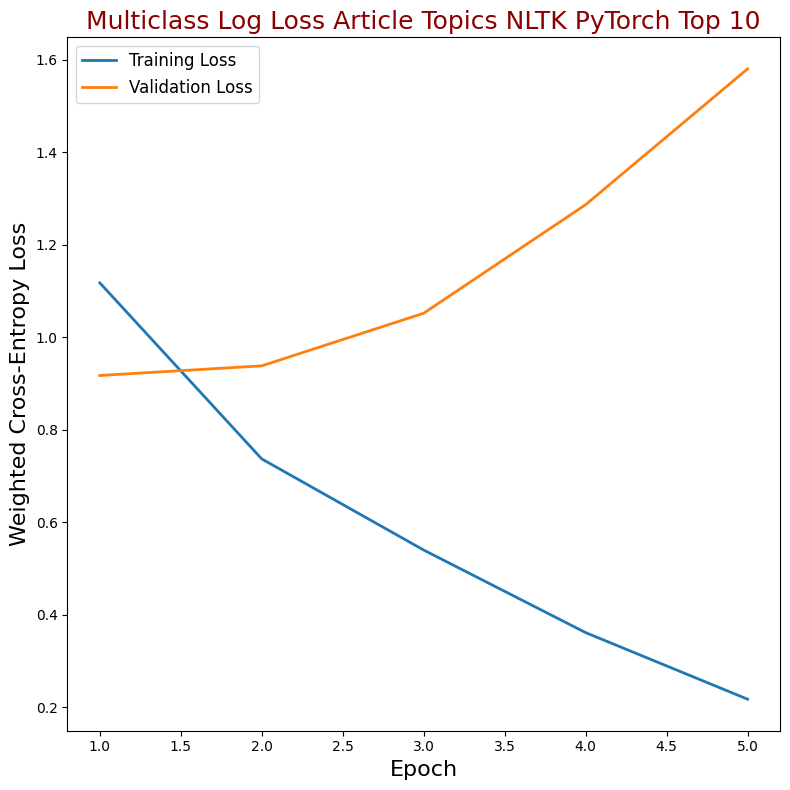


FINAL TEST RESULTS
Unweighted Cross-Entropy Loss : 1.2792
Sklearn Log Loss              : 1.2666
Accuracy                      : 0.6966
Macro F1                      : 0.6533
Weighted F1                   : 0.7018


In [ ]:
# --------------------------------------------------------
# PLOT TRAINING / VALIDATION LOG LOSS
# AND EVALUATE FINAL TEST PERFORMANCE
# --------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss
)

# --------------------------------------------------------
# LOSS CURVE
# --------------------------------------------------------

epochs = np.arange(
    1,
    len(training_loss) + 1
)

plt.figure(figsize=(8, 8))

plt.plot(
    epochs,
    training_loss,
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_loss,
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch",
    fontsize=16
)

plt.ylabel(
    "Weighted Cross-Entropy Loss",
    fontsize=16
)

plt.title(
    "Multiclass Log Loss Article Topics NLTK PyTorch Top 10",
    fontsize=18,
    color="darkred"
)

plt.legend(fontsize=12)

plt.tight_layout()

plt.savefig(
    "Multiclass_LogLoss_ArticleTopics_NLTKPytorch_Top10.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# --------------------------------------------------------
# TEST SET EVALUATION
# --------------------------------------------------------

test_loader = DataLoader(
    dataset=test_data,
    batch_size=batch_size,
    collate_fn=sparse_collate
)

# Use unweighted cross-entropy for final test reporting
test_loss_function = nn.CrossEntropyLoss()

model.eval()

all_probabilities = []
all_predictions = []
all_truths = []

test_loss = 0.0
n_batches = 0

with pt.no_grad():

    for input_batch, truth_batch in test_loader:

        input_batch = input_batch.to(device)
        truth_batch = truth_batch.to(device).long()

        outputs = model(input_batch)

        loss = test_loss_function(
            outputs,
            truth_batch
        )

        test_loss += loss.item()
        n_batches += 1

        probabilities = pt.softmax(outputs, dim=1)
        predictions = pt.argmax(outputs, dim=1)

        all_probabilities.extend(probabilities.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_truths.extend(truth_batch.cpu().numpy())

# --------------------------------------------------------
# FINAL METRICS
# --------------------------------------------------------

all_probabilities = np.array(all_probabilities)
all_predictions = np.array(all_predictions)
all_truths = np.array(all_truths)

final_test_loss = test_loss / n_batches

final_log_loss = log_loss(
    all_truths,
    all_probabilities,
    labels=np.arange(num_classes))

test_accuracy = accuracy_score(
    all_truths,
    all_predictions
)

macro_f1 = f1_score(
    all_truths,
    all_predictions,
    average="macro"
)

weighted_f1 = f1_score(
    all_truths,
    all_predictions,
    average="weighted"
)

# --------------------------------------------------------
# REPORT RESULTS
# --------------------------------------------------------

print("\n" + "=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)

print(
    f"Unweighted Cross-Entropy Loss : {final_test_loss:.4f}"
)

print(
    f"Sklearn Log Loss              : {final_log_loss:.4f}"
)

print(
    f"Accuracy                      : {test_accuracy:.4f}"
)

print(
    f"Macro F1                      : {macro_f1:.4f}"
)

print(
    f"Weighted F1                   : {weighted_f1:.4f}"
)

print("=" * 50)

Generating test predictions...


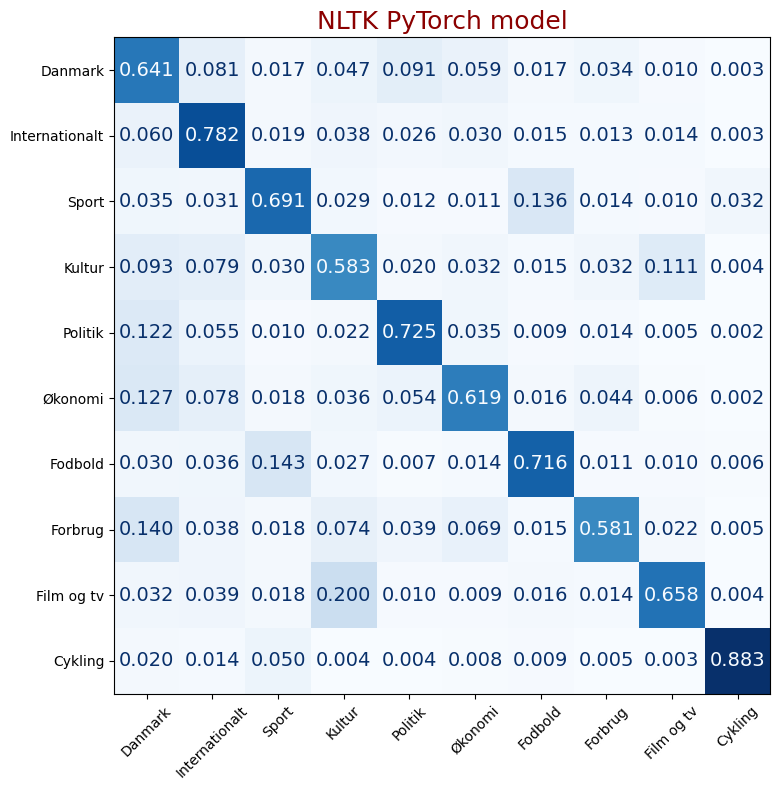

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# GET TEST PREDICTIONS
# --------------------------------------------------------

model.eval()

all_predictions = []
all_truths = []

print("Generating test predictions...")

with pt.no_grad():

    for input_batch, truth_batch in test_loader:

        input_batch = input_batch.to(device)

        outputs = model(input_batch)
        predictions = pt.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_truths.extend(truth_batch.cpu().numpy())

# --------------------------------------------------------
# DEFINE DESIRED TOPIC ORDER
# --------------------------------------------------------

desired_order = [
    "Danmark",
    "Internationalt",
    "Sport",
    "Kultur",
    "Politik",
    "Økonomi",
    "Fodbold",
    "Forbrug",
    "Film og tv",
    "Cykling"
]

# Convert topic names to encoded integer labels
label_order = label_encoder.transform(desired_order)

# --------------------------------------------------------
# NORMALIZED CONFUSION MATRIX
# --------------------------------------------------------

cm = confusion_matrix(
    all_truths,
    all_predictions,
    labels=label_order,
    normalize="true"
)

cm = np.round(cm, 3)

# --------------------------------------------------------
# PLOT CONFUSION MATRIX
# --------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=desired_order
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap=plt.cm.Blues,
    colorbar=False,
    values_format=".3f"
)

ax.set_xlabel("")
ax.set_ylabel("")

for t in disp.text_.ravel():
    t.set_fontsize(14)

plt.title(
    "NLTK PyTorch model",
    fontsize=18,
    color="darkred"
)

plt.tight_layout()

plt.savefig(
    "confusion_matrix_multiclass_NLTKPytorch.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Generating test prediction probabilities...


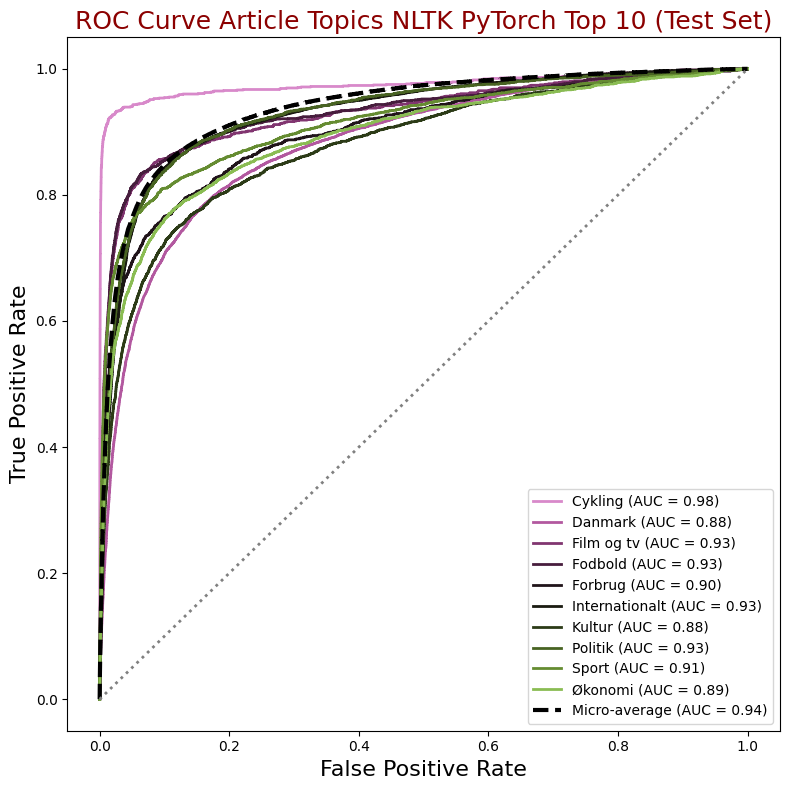

Micro-average AUC: 0.9377
Accuracy: 30270/43456 = 0.6966


In [14]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------------
# GET TEST PROBABILITIES AND PREDICTIONS
# --------------------------------------------------------

model.eval()

all_probabilities = []
all_predictions = []
all_truths = []

print("Generating test prediction probabilities...")

with pt.no_grad():

    for input_batch, truth_batch in test_loader:

        input_batch = input_batch.to(device)

        outputs = model(input_batch)

        probabilities = pt.softmax(outputs, dim=1)
        predictions = pt.argmax(outputs, dim=1)

        all_probabilities.extend(probabilities.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_truths.extend(truth_batch.cpu().numpy())

all_probabilities = np.array(all_probabilities)
all_predictions = np.array(all_predictions)
all_truths = np.array(all_truths)

# --------------------------------------------------------
# ACCURACY
# --------------------------------------------------------

correct_guesses = np.sum(all_predictions == all_truths)
total_datapoints = len(all_truths)
accuracy = correct_guesses / total_datapoints

# --------------------------------------------------------
# BINARIZE LABELS
# --------------------------------------------------------

classes = label_encoder.classes_
num_classes = len(classes)

truths_binarized = label_binarize(
    all_truths,
    classes=np.arange(num_classes)
)

# --------------------------------------------------------
# ROC CURVES
# --------------------------------------------------------

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):

    fpr[i], tpr[i], _ = roc_curve(
        truths_binarized[:, i],
        all_probabilities[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

# --------------------------------------------------------
# MICRO AVERAGE
# --------------------------------------------------------

fpr["micro"], tpr["micro"], _ = roc_curve(
    truths_binarized.ravel(),
    all_probabilities.ravel()
)

roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# --------------------------------------------------------
# COLORS
# --------------------------------------------------------

cmap = plt.get_cmap("vanimo")

colors = cmap(
    np.linspace(0.1, 0.9, num_classes)
)

# --------------------------------------------------------
# PLOT
# --------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

for i, color in zip(range(num_classes), colors):

    ax.plot(
        fpr[i],
        tpr[i],
        color=color,
        linewidth=2,
        label=f"{classes[i]} (AUC = {roc_auc[i]:.2f})"
    )

ax.plot(
    fpr["micro"],
    tpr["micro"],
    color="black",
    linestyle="--",
    linewidth=3,
    label=f"Micro-average (AUC = {roc_auc['micro']:.2f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    linewidth=2,
    color="gray"
)

plt.title(
    "ROC Curve Article Topics NLTK PyTorch Top 10 (Test Set)",
    fontsize=18,
    color="darkred"
)

plt.xlabel("False Positive Rate", fontsize=16)
plt.ylabel("True Positive Rate", fontsize=16)

plt.legend(fontsize=10, loc="lower right")

plt.tight_layout()

plt.savefig(
    "Multiclass_ROC_ArticleTopics_NLTKPytorch_Top10_TEST.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# --------------------------------------------------------
# PRINT RESULTS
# --------------------------------------------------------

print(f"Micro-average AUC: {roc_auc['micro']:.4f}")
print(f"Accuracy: {correct_guesses}/{total_datapoints} = {accuracy:.4f}")